In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None 


In [2]:
test = pd.read_csv('/kaggle/input/blood-vessel-segmentation/sample_submission.csv')
test.head()

,id,rle
0,kidney_5_0000,1 1 100 10
1,kidney_5_0001,1 1 100 10
2,kidney_6_0000,1 0
3,kidney_6_0001,1 0


In [3]:
train = pd.read_csv('/kaggle/input/blood-vessel-segmentation/train_rles.csv')
train.head()

,id,rle
0,kidney_1_dense_0000,1 0
1,kidney_1_dense_0001,1 0
2,kidney_1_dense_0002,1 0
3,kidney_1_dense_0003,1 0
4,kidney_1_dense_0004,1 0


In [4]:
combined = pd.concat([train,test])
combined.head()

,id,rle
0,kidney_1_dense_0000,1 0
1,kidney_1_dense_0001,1 0
2,kidney_1_dense_0002,1 0
3,kidney_1_dense_0003,1 0
4,kidney_1_dense_0004,1 0


In [5]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7433 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      7433 non-null   object
 1   rle     7433 non-null   object
dtypes: object(2)
memory usage: 174.2+ KB


In [6]:
combined.dtypes

id     object
rle    object
dtype: object

In [7]:
combined.describe().T

,count,unique,top,freq
id,7433,7433,kidney_1_dense_0000,1
rle,7433,7035,1 0,374


In [8]:
combined.isnull().sum()/len(combined*100)

id     0.0
rle    0.0
dtype: float64

In [9]:
combined.columns

Index(['id', 'rle'], dtype='object')

<Axes: >

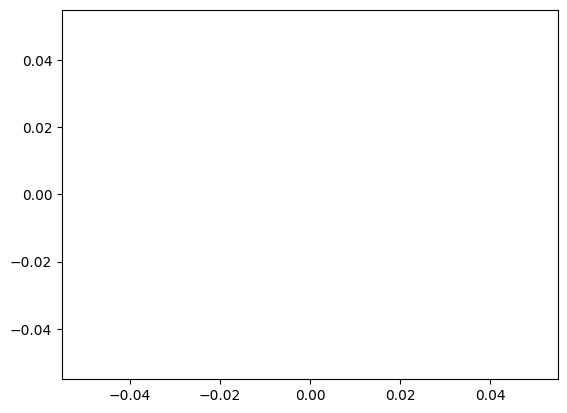

In [10]:

sns.scatterplot(combined)

In [11]:
combined.skew



<bound method DataFrame.skew of                         id         rle
0      kidney_1_dense_0000         1 0
1      kidney_1_dense_0001         1 0
2      kidney_1_dense_0002         1 0
3      kidney_1_dense_0003         1 0
4      kidney_1_dense_0004         1 0
...                    ...         ...
7428  kidney_3_sparse_1034         1 0
0            kidney_5_0000  1 1 100 10
1            kidney_5_0001  1 1 100 10
2            kidney_6_0000         1 0
3            kidney_6_0001         1 0

[7433 rows x 2 columns]>

In [12]:
combined.kurt

<bound method DataFrame.kurt of                         id         rle
0      kidney_1_dense_0000         1 0
1      kidney_1_dense_0001         1 0
2      kidney_1_dense_0002         1 0
3      kidney_1_dense_0003         1 0
4      kidney_1_dense_0004         1 0
...                    ...         ...
7428  kidney_3_sparse_1034         1 0
0            kidney_5_0000  1 1 100 10
1            kidney_5_0001  1 1 100 10
2            kidney_6_0000         1 0
3            kidney_6_0001         1 0

[7433 rows x 2 columns]>

In [13]:
cat_cols = combined.select_dtypes(include='object')

In [15]:
for i in cat_cols:
    print(i)
    data=(combined[i].value_counts())
    print(''*50)

id

rle



In [18]:
num_cols = combined.select_dtypes(include='number')

In [19]:
for i in num_cols:
    print(i)
    data=(combined[i].value_counts())
    print(''*50)

In [23]:
x = combined[['rle']]

In [24]:
y = combined[['rle']]

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
lr = LinearRegression()

In [33]:
x = i
num_cols = combined.select_dtypes(include='number')
for i in num_cols:
    sns.boxplot(data=combined)
    print('\n')
    plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


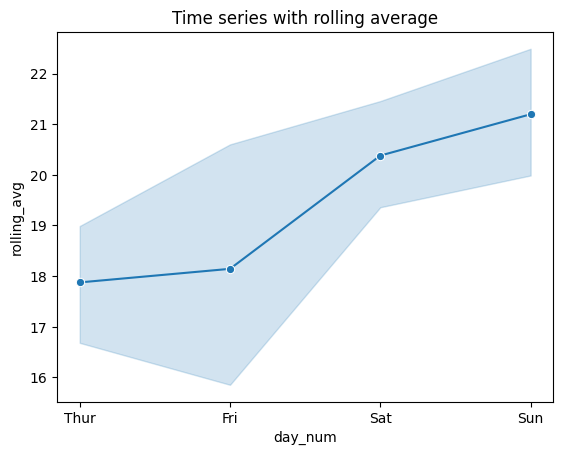

In [34]:
df_tips = sns.load_dataset("tips")
df_tips['day_num'] = df_tips['day'].astype('category').cat.codes

df_tips['rolling_avg'] = df_tips['total_bill'].rolling(window=3).mean()

sns.lineplot(x='day_num', y='rolling_avg', data=df_tips, marker='o')
plt.xticks(ticks=[0,1,2,3], labels=['Thur','Fri','Sat','Sun'])
plt.title("Time series with rolling average")
plt.show()